# PoC - Detección de anomalías de comportamiento en Login Log y Activity Log

## Objetivo
Construir una primera **PoC de detección de anomalías de comportamiento** en el uso de una aplicación tipo gestor de contraseñas, utilizando técnicas de **Machine Learning no supervisado** capaces de aprender el comportamiento habitual de cada usuario y detectar desviaciones relevantes respecto a ese patrón normal.

## Enfoque del proyecto
El sistema no se basa en reglas fijas para clasificar directamente una actividad como anómala, sino en el aprendizaje del comportamiento normal observado en los datos. Para ello, se ha utilizado un enfoque de **detección de anomalías por usuario**, entrenando un modelo independiente para cada uno de ellos mediante **IsolationForest**.

Las reglas de negocio se han utilizado únicamente como referencia para construir un dataset sintético coherente con el dominio del problema, pero no como mecanismo final de etiquetado del modelo.

## Patrones de comportamiento definidos para la generación de datos

### 1. Login Log
Los datos sintéticos de login se generan siguiendo patrones de comportamiento esperados para cada usuario:

- Los accesos habituales se realizan principalmente de **lunes a viernes**.
- Usuario 1 (**Matteo Nicolosi**): horario habitual entre **09:00 y 13:00**.
- Usuario 2 (**Diego Scardino**): horario habitual entre **09:00 y 17:00**.
- Usuario 3 (**Emilio Sardo**): horario habitual entre **10:00 y 18:00**.

### 2. Activity Log
Las actividades sintéticas se generan siguiendo combinaciones habituales de uso para cada usuario:

- Las acciones normales se realizan principalmente de **lunes a viernes**.
- Cada usuario presenta un patrón propio de acceso a **elementos**, **entidades** y **acciones**.
- Acciones disponibles:
  - `1000000` → Visualize
  - `1000001` → Create
  - `1000002` → Edit
  - `1000003` → Delete
  - `1000004` → Copy
  - `1000005` → Share

### 3. Objetivos del modelo
El objetivo del modelo es:

- Aprender el comportamiento normal de cada usuario a partir de sus actividades históricas.
- Detectar actividades que se desvíen del patrón habitual del usuario.
- Identificar combinaciones poco frecuentes o sospechosas de:
  - horario
  - elemento
  - entidad
  - acción
- Asignar un **score de anomalía** a cada actividad para estimar su grado de rareza.

---

# PoC - Rilevamento di anomalie comportamentali nei Login Log e negli Activity Log

## Obiettivo
Costruire una prima **PoC di rilevamento delle anomalie comportamentali** nell’utilizzo di un’applicazione simile a un gestore di password, utilizzando tecniche di **Machine Learning non supervisionato** capaci di apprendere il comportamento abituale di ciascun utente e rilevare deviazioni rilevanti rispetto a quel pattern normale.

## Approccio del progetto
Il sistema non si basa su regole fisse per classificare direttamente un’attività come anomala, ma sull’apprendimento del comportamento normale osservato nei dati. A tal fine, è stato utilizzato un approccio di **rilevamento delle anomalie per utente**, addestrando un modello indipendente per ciascuno di essi mediante **IsolationForest**.

Le regole di business sono state utilizzate unicamente come riferimento per costruire un dataset sintetico coerente con il dominio del problema, ma non come meccanismo finale di etichettatura del modello.

## Pattern di comportamento definiti per la generazione dei dati

### 1. Login Log
I dati sintetici di login vengono generati seguendo pattern di comportamento attesi per ciascun utente:

- Gli accessi abituali vengono effettuati principalmente dal **lunedì al venerdì**.
- Utente 1 (**Matteo Nicolosi**): orario abituale tra le **09:00 e le 13:00**.
- Utente 2 (**Diego Scardino**): orario abituale tra le **09:00 e le 17:00**.
- Utente 3 (**Emilio Sardo**): orario abituale tra le **10:00 e le 18:00**.

### 2. Activity Log
Le attività sintetiche vengono generate seguendo combinazioni abituali di utilizzo per ciascun utente:

- Le azioni normali vengono eseguite principalmente dal **lunedì al venerdì**.
- Ogni utente presenta un pattern proprio di accesso a **elementi**, **entità** e **azioni**.
- Azioni disponibili:
  - `1000000` → Visualize
  - `1000001` → Create
  - `1000002` → Edit
  - `1000003` → Delete
  - `1000004` → Copy
  - `1000005` → Share

### 3. Obiettivi del modello
L’obiettivo del modello è:

- Apprendere il comportamento normale di ciascun utente a partire dalle sue attività storiche.
- Rilevare attività che si discostano dal pattern abituale dell’utente.
- Identificare combinazioni poco frequenti o sospette di:
  - orario
  - elemento
  - entità
  - azione
- Assegnare un **anomaly score** a ciascuna attività per stimarne il grado di rarità.

In [150]:
# =========================
# IMPORTS GENERALES
# IMPORT GENERALI
# =========================

# pandas y numpy se utilizan para trabajar con datos tabulares
# y realizar operaciones numéricas de forma eficiente.
# pandas e numpy si usano per lavorare con dati tabellari
# e per eseguire operazioni numeriche in modo efficiente.
import pandas as pd
import numpy as np

# matplotlib y seaborn se utilizan para crear gráficas y visualizaciones
# que ayuden a interpretar mejor el comportamiento de los datos.
# matplotlib e seaborn si usano per creare grafici e visualizzazioni
# che aiutano a interpretare meglio il comportamento dei dati.
import matplotlib.pyplot as plt
import seaborn as sns

# SQLAlchemy se utiliza para conectar el notebook con PostgreSQL
# y cargar directamente las tablas de la base de datos.
# SQLAlchemy si usa per collegare il notebook a PostgreSQL
# e caricare direttamente le tabelle del database.
from sqlalchemy import create_engine

# Herramientas de scikit-learn para entrenar y evaluar modelos
# de detección de anomalías.
# Strumenti di scikit-learn per addestrare e valutare modelli
# di rilevamento anomalie.
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# os y sys permiten trabajar con rutas del sistema y añadir carpetas
# al path de Python si fuese necesario.
# os e sys permettono di lavorare con i percorsi del sistema e aggiungere cartelle
# al path di Python se necessario.
import os
import sys

# warnings se utiliza para ocultar avisos no críticos y mantener
# la salida del notebook más limpia.
# warnings si usa per nascondere avvisi non critici e mantenere
# l'output del notebook più pulito.
import warnings
warnings.filterwarnings("ignore")

# Configuración visual de pandas para mostrar más columnas y filas
# cuando inspeccionamos los DataFrames.
# Configurazione visiva di pandas per mostrare più colonne e righe
# quando ispezioniamo i DataFrame.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Configuración estética general de seaborn para que las gráficas
# tengan un formato más claro y profesional.
# Configurazione estetica generale di seaborn affinché i grafici
# abbiano un aspetto più chiaro e professionale.
sns.set_theme(style="whitegrid")

In [151]:
# =========================
# CONEXIÓN A POSTGRESQL
# CONNESSIONE A POSTGRESQL
# =========================

# Definimos la configuración de conexión con la base de datos PostgreSQL.
# Qui si indican el host, el puerto, el nombre de la base de datos,
# el usuario y la contraseña.
# Definiamo la configurazione di connessione al database PostgreSQL.
# Qui si indicano host, porta, nome del database,
# utente e password.
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "dbname": "Audit",
    "user": "dani",
    "password": ""
}

# Construimos la URL de conexión en formato compatible con SQLAlchemy.
# Esta URL será utilizada por create_engine para abrir la conexión
# entre el notebook y PostgreSQL.
# Costruiamo l'URL di connessione in formato compatibile con SQLAlchemy.
# Questo URL verrà utilizzato da create_engine per aprire la connessione
# tra il notebook e PostgreSQL.
connection_url = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
)

# Creamos el motor de conexión con SQLAlchemy.
# A partir de este objeto podremos cargar tablas SQL directamente
# en DataFrames de pandas mediante consultas.
# Creiamo il motore di connessione con SQLAlchemy.
# A partire da questo oggetto potremo caricare tabelle SQL direttamente
# in DataFrame di pandas tramite query.
engine = create_engine(connection_url)

# Mensaje de confirmación para comprobar que la configuración se ha ejecutado.
# Messaggio di conferma per verificare che la configurazione sia stata eseguita.
print("Conexión a PostgreSQL configurada correctamente.")

Conexión a PostgreSQL configurada correctamente.


In [152]:
# =========================
# CARGA DE DATOS DESDE POSTGRESQL
# CARICAMENTO DEI DATI DA POSTGRESQL
# =========================

# Consulta SQL para cargar la tabla login_log.
# Incluye el identificador del login, el usuario, el resultado,
# el número de intento y las marcas temporales de login y logout.
# Query SQL per caricare la tabella login_log.
# Include l'identificativo del login, l'utente, il risultato,
# il numero di tentativo e i timestamp di login e logout.
login_query = """
SELECT 
    login_log_id,
    user_id,
    result,
    attempt,
    logged_at,
    logout_at
FROM login_log
ORDER BY login_log_id
"""

# Consulta SQL para cargar la tabla activity_log.
# Incluye el identificador de la actividad, el usuario,
# el elemento, la entidad, la acción realizada y la fecha/hora.
# Query SQL per caricare la tabella activity_log.
# Include l'identificativo dell'attività, l'utente,
# l'elemento, l'entità, l'azione eseguita e la data/ora.
activity_query = """
SELECT
    activity_log_id,
    user_id,
    element_id,
    entity_id,
    action_id,
    logged_at
FROM activity_log
ORDER BY activity_log_id
"""

# Cargamos ambas consultas SQL en DataFrames de pandas.
# In questo modo possiamo trabajar con los datos de PostgreSQL
# igual que antes trabajábamos con los CSV.
# Carichiamo entrambe le query SQL in DataFrame di pandas.
# In questo modo possiamo lavorare con i dati di PostgreSQL
# come prima facevamo con i file CSV.
keyoverLogin = pd.read_sql(login_query, engine)
keyoverActivity = pd.read_sql(activity_query, engine)

# Mostramos las dimensiones de cada DataFrame para comprobar
# que la carga de datos se ha realizado correctamente.
# Mostriamo le dimensioni di ciascun DataFrame per verificare
# che il caricamento dei dati sia avvenuto correttamente.
print("Dimensiones Login Log:", keyoverLogin.shape)
print("Dimensiones Activity Log:", keyoverActivity.shape)

Dimensiones Login Log: (110009, 6)
Dimensiones Activity Log: (110011, 6)


In [153]:
# =========================
# VISTA PREVIA DE LOS DATASETS
# ANTEPRIMA DEI DATASET
# =========================

# Mostramos las primeras filas del dataset de login para comprobar
# cómo están organizadas sus columnas y qué tipo de información contiene.
# Mostriamo le prime righe del dataset di login per verificare
# come sono organizzate le colonne e quale tipo di informazione contiene.
print("LOGIN LOG")
display(keyoverLogin.head())

# Mostramos las primeras filas del dataset de actividad para observar
# la estructura de los registros y entender qué variables se usarán después
# en el análisis exploratorio y en el modelo de machine learning.
# Mostriamo le prime righe del dataset di attività per osservare
# la struttura dei record e capire quali variabili verranno poi usate
# nell'analisi esplorativa e nel modello di machine learning.
print("\nACTIVITY LOG")
display(keyoverActivity.head())

LOGIN LOG


,login_log_id,user_id,result,attempt,logged_at,logout_at
0,243023,3,True,1,2025-12-17 15:12:43,2025-12-17 15:48:43
1,243024,1,True,1,2025-12-24 09:31:40,2025-12-24 10:57:40
2,243025,3,True,1,2026-01-21 15:41:35,2026-01-21 15:58:35
3,243026,2,True,1,2026-01-05 15:03:35,2026-01-05 16:27:35
4,243027,3,True,1,2026-03-18 13:42:25,2026-03-18 14:42:25



ACTIVITY LOG


,activity_log_id,user_id,element_id,entity_id,action_id,logged_at
0,243041,1,2,1,1000004,2026-03-24 11:28:39
1,243042,1,2,1,1000000,2026-03-12 09:43:11
2,243043,1,2,1,1000000,2026-03-12 10:20:46
3,243044,1,1,1,1000005,2026-04-07 12:10:38
4,243045,2,3,1,1000000,2026-03-09 15:38:28


In [154]:
# info() nos permite revisar:
# - número de filas
# - número de columnas
# - tipo de dato de cada columna
# - cuántos valores no nulos hay
# Esto ayuda a detectar problemas antes del análisis.

# info() ci permette di controllare:
# - numero di righe
# - numero di colonne
# - tipo di dato di ogni colonna
# - quanti valori non nulli ci sono
# Questo aiuta a rilevare problemi prima dell'analisi.

print("======== LOGIN LOG INFO ========")
print(keyoverLogin.info())

print("\n======== ACTIVITY LOG INFO ========")
print(keyoverActivity.info())

======== LOGIN LOG INFO ========
<class 'pandas.DataFrame'>
RangeIndex: 110009 entries, 0 to 110008
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   login_log_id  110009 non-null  int64         
 1   user_id       110009 non-null  int64         
 2   result        110009 non-null  bool          
 3   attempt       110009 non-null  int64         
 4   logged_at     110009 non-null  datetime64[us]
 5   logout_at     101203 non-null  datetime64[us]
dtypes: bool(1), datetime64[us](2), int64(3)
memory usage: 4.3 MB
None

======== ACTIVITY LOG INFO ========
<class 'pandas.DataFrame'>
RangeIndex: 110011 entries, 0 to 110010
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   activity_log_id  110011 non-null  int64         
 1   user_id          110011 non-null  int64         
 2   element_id       110011 non-null

In [155]:
# Comprobamos si hay valores nulos en el dataset de login.
# Esto es importante porque los modelos no suelen trabajar bien con nulos.
# Controlliamo se ci sono valori nulli nel dataset di login.
# Questo è importante perché i modelli di solito non lavorano bene con valori nulli.
print("VALORI NULLI LOGIN LOG")
display(keyoverLogin.isnull().sum())

# Comprobamos si hay valores nulos en el dataset de actividad.
# Controlliamo se ci sono valori nulli nel dataset di attività.
print("\nVALORI NULLI ACTIVITY LOG")
display(keyoverActivity.isnull().sum())

# También revisamos si hay filas duplicadas.
# Los duplicados pueden introducir sesgos en el entrenamiento.
# Controlliamo anche se ci sono righe duplicate.
# I duplicati possono introdurre bias nell'addestramento.
print("\nDUPLICATI LOGIN LOG:", keyoverLogin.duplicated().sum())
print("DUPLICATI ACTIVITY LOG:", keyoverActivity.duplicated().sum())

VALORI NULLI LOGIN LOG


login_log_id       0
user_id            0
result             0
attempt            0
logged_at          0
logout_at       8806
dtype: int64


VALORI NULLI ACTIVITY LOG


activity_log_id    0
user_id            0
element_id         0
entity_id          0
action_id          0
logged_at          0
dtype: int64


DUPLICATI LOGIN LOG: 0
DUPLICATI ACTIVITY LOG: 0


In [156]:
# =========================
# CONVERSIÓN DE FECHAS
# CONVERSIONE DELLE DATE
# =========================

# Convertimos las columnas temporales de login a formato datetime.
# Esto permitirá extraer información temporal de forma sencilla.
# Convertiamo le colonne temporali di login nel formato datetime.
# Questo permetterà di estrarre informazioni temporali in modo semplice.
keyoverLogin["logged_at"] = pd.to_datetime(keyoverLogin["logged_at"], errors="coerce")
keyoverLogin["logout_at"] = pd.to_datetime(keyoverLogin["logout_at"], errors="coerce")

# Hacemos lo mismo con la columna temporal del dataset de actividad.
# Facciamo lo stesso con la colonna temporale del dataset di attività.
keyoverActivity["logged_at"] = pd.to_datetime(keyoverActivity["logged_at"], errors="coerce")

# Mensaje de confirmación.
# Messaggio di conferma.
print("Conversione delle date completata correttamente.")

Conversione delle date completata correttamente.


In [157]:
# =========================
# FEATURE ENGINEERING LOGIN
# FEATURE ENGINEERING LOGIN
# =========================

# Creamos una copia del dataset original para trabajar sobre ella
# sin modificar directamente keyoverLogin.
# Creiamo una copia del dataset originale per lavorarci sopra
# senza modificare direttamente keyoverLogin.
login_df = keyoverLogin.copy()

# Extraemos variables temporales básicas del momento del login.
# Estraiamo variabili temporali di base dal momento del login.
login_df["hour"] = login_df["logged_at"].dt.hour
login_df["minute"] = login_df["logged_at"].dt.minute
login_df["day_of_week"] = login_df["logged_at"].dt.dayofweek
login_df["date"] = login_df["logged_at"].dt.date

# Calculamos la duración de la sesión en minutos.
# Si logout_at es nulo, el resultado quedará como NaN.
# Calcoliamo la durata della sessione in minuti.
# Se logout_at è nullo, il risultato rimarrà come NaN.
login_df["session_duration_min"] = (
    (login_df["logout_at"] - login_df["logged_at"]).dt.total_seconds() / 60
)

# Creamos una variable simple para indicar si el login ocurrió
# en día laborable o en fin de semana.
# Creiamo una variabile semplice per indicare se il login è avvenuto
# in un giorno lavorativo o nel fine settimana.
login_df["is_weekday"] = (login_df["day_of_week"] < 5).astype(int)

# Creamos una franja horaria aproximada para facilitar análisis posteriores.
# Creiamo una fascia oraria approssimativa per facilitare analisi successive.
login_df["time_block"] = pd.cut(
    login_df["hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["night", "morning", "afternoon", "evening"]
)

# Mostramos una vista previa del dataset enriquecido.
# Mostriamo un'anteprima del dataset arricchito.
display(login_df.head())

,login_log_id,user_id,result,attempt,logged_at,logout_at,hour,minute,day_of_week,date,session_duration_min,is_weekday,time_block
0,243023,3,True,1,2025-12-17 15:12:43,2025-12-17 15:48:43,15,12,2,2025-12-17,36.0,1,afternoon
1,243024,1,True,1,2025-12-24 09:31:40,2025-12-24 10:57:40,9,31,2,2025-12-24,86.0,1,morning
2,243025,3,True,1,2026-01-21 15:41:35,2026-01-21 15:58:35,15,41,2,2026-01-21,17.0,1,afternoon
3,243026,2,True,1,2026-01-05 15:03:35,2026-01-05 16:27:35,15,3,0,2026-01-05,84.0,1,afternoon
4,243027,3,True,1,2026-03-18 13:42:25,2026-03-18 14:42:25,13,42,2,2026-03-18,60.0,1,afternoon


In [158]:
# =========================
# FEATURE ENGINEERING ACTIVITY
# FEATURE ENGINEERING ACTIVITY
# =========================

# Creamos una copia del dataset original para trabajar sobre ella
# sin modificar directamente keyoverActivity.
# Creiamo una copia del dataset originale per lavorarci sopra
# senza modificare direttamente keyoverActivity.
activity_df = keyoverActivity.copy()

# Diccionarios auxiliares para hacer el dataset más legible.
# Dizionari di supporto per rendere il dataset più leggibile.
user_names = {
    1: "Matteo Nicolosi",
    2: "Diego Scardino",
    3: "Emilio Sardo"
}

action_names = {
    1000000: "Visualize",
    1000001: "Create",
    1000002: "Edit",
    1000003: "Delete",
    1000004: "Copy",
    1000005: "Share"
}

entity_names = {
    1: "Password",
    2: "Folder",
    3: "Group"
}

# Añadimos el nombre del usuario, de la acción y de la entidad
# para facilitar la lectura del análisis.
# Aggiungiamo il nome dell'utente, dell'azione e dell'entità
# per facilitare la lettura dell'analisi.
activity_df["user_name"] = activity_df["user_id"].map(user_names)
activity_df["action_name"] = activity_df["action_id"].map(action_names)
activity_df["entity_name"] = activity_df["entity_id"].map(entity_names)

# Extraemos variables temporales básicas a partir del timestamp de la actividad.
# Estraiamo variabili temporali di base a partire dal timestamp dell'attività.
activity_df["hour"] = activity_df["logged_at"].dt.hour
activity_df["minute"] = activity_df["logged_at"].dt.minute
activity_df["day_of_week"] = activity_df["logged_at"].dt.dayofweek
activity_df["date"] = activity_df["logged_at"].dt.date

# Indicamos si la actividad ocurrió en día laborable.
# Indichiamo se l'attività è avvenuta in un giorno lavorativo.
activity_df["is_weekday"] = (activity_df["day_of_week"] < 5).astype(int)

# Creamos una franja horaria aproximada para ayudar en el análisis.
# Creiamo una fascia oraria approssimativa per aiutare nell'analisi.
activity_df["time_block"] = pd.cut(
    activity_df["hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["night", "morning", "afternoon", "evening"]
)

# Mostramos una vista previa del dataset enriquecido.
# Mostriamo un'anteprima del dataset arricchito.
display(activity_df.head())

,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,entity_name,hour,minute,day_of_week,date,is_weekday,time_block
0,243041,1,2,1,1000004,2026-03-24 11:28:39,Matteo Nicolosi,Copy,Password,11,28,1,2026-03-24,1,morning
1,243042,1,2,1,1000000,2026-03-12 09:43:11,Matteo Nicolosi,Visualize,Password,9,43,3,2026-03-12,1,morning
2,243043,1,2,1,1000000,2026-03-12 10:20:46,Matteo Nicolosi,Visualize,Password,10,20,3,2026-03-12,1,morning
3,243044,1,1,1,1000005,2026-04-07 12:10:38,Matteo Nicolosi,Share,Password,12,10,1,2026-04-07,1,afternoon
4,243045,2,3,1,1000000,2026-03-09 15:38:28,Diego Scardino,Visualize,Password,15,38,0,2026-03-09,1,afternoon


Record per utente nel Login Log


user_name
Matteo Nicolosi    49312
Diego Scardino     33184
Emilio Sardo       27513
Name: count, dtype: int64

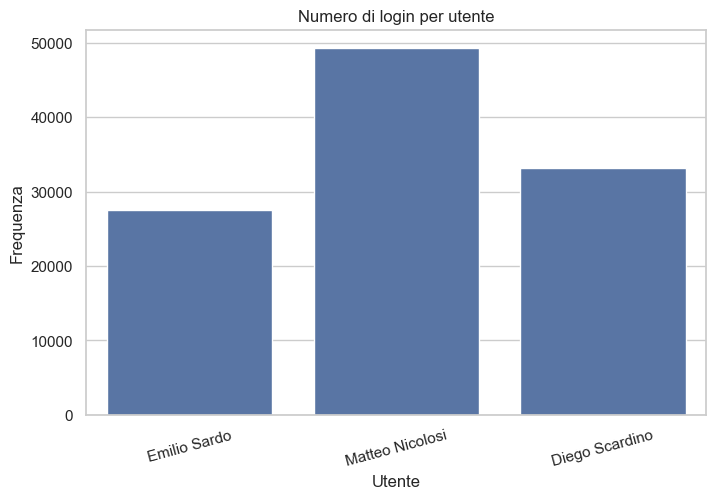

In [159]:
# =========================
# DISTRIBUCIÓN DE LOGINS POR USUARIO
# DISTRIBUZIONE DEI LOGIN PER UTENTE
# =========================

# Creamos una columna temporal con el nombre del usuario
# a partir del identificador numérico.
# Creiamo una colonna temporanea con il nome dell'utente
# a partire dall'identificativo numerico.
login_df["user_name"] = login_df["user_id"].map(user_names)

# Analizamos cuántos registros de login tiene cada usuario.
# Esto permite comprobar si todos los usuarios tienen
# suficiente representación en el dataset.
# Analizziamo quanti record di login ha ogni utente.
# Questo permette di verificare se tutti gli utenti hanno
# una rappresentazione sufficiente nel dataset.
print("Record per utente nel Login Log")
display(login_df["user_name"].value_counts())

# Visualización gráfica del número de logins por usuario.
# Visualizzazione grafica del numero di login per utente.
plt.figure(figsize=(8, 5))
sns.countplot(data=login_df, x="user_name")
plt.title("Numero di login per utente")
plt.xlabel("Utente")
plt.ylabel("Frequenza")
plt.xticks(rotation=15)
plt.show()

# explicar graficas

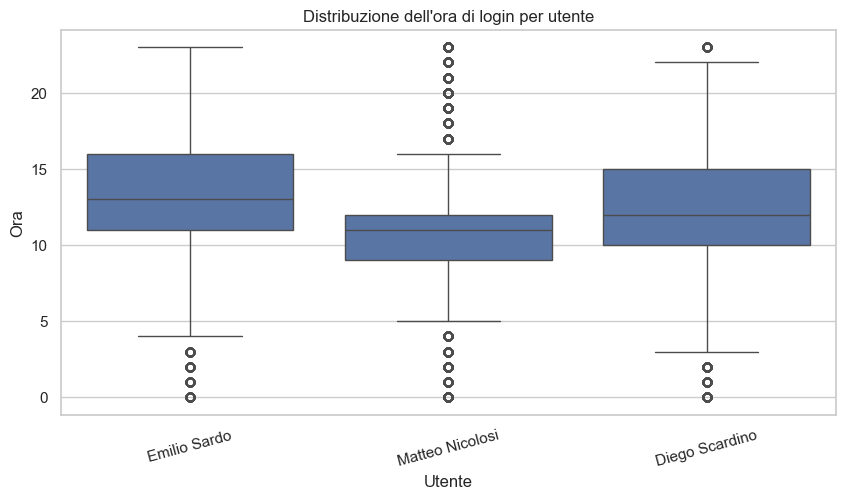

In [160]:
# =========================
# BOXPLOT DE LA HORA DE LOGIN POR USUARIO
# BOXPLOT DELL'ORA DI LOGIN PER UTENTE
# =========================

# El boxplot permite observar la distribución de la hora de login
# para cada usuario y detectar visualmente posibles valores poco frecuentes.
# Il boxplot permette di osservare la distribuzione dell'ora di login
# per ciascun utente e di rilevare visivamente possibili valori poco frequenti.
plt.figure(figsize=(10, 5))
sns.boxplot(data=login_df, x="user_name", y="hour")
plt.title("Distribuzione dell'ora di login per utente")
plt.xlabel("Utente")
plt.ylabel("Ora")
plt.xticks(rotation=15)
plt.show()


# explicar grafica

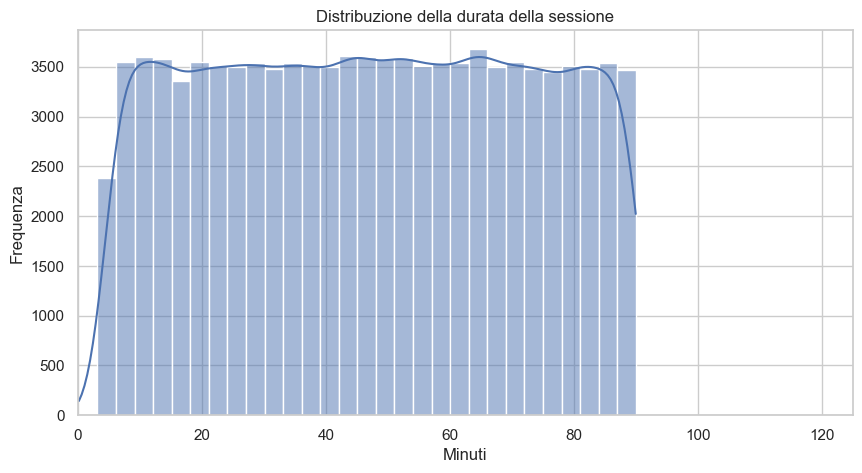

In [161]:
# Histograma de la duración de las sesiones de login.
# Se añade también una curva KDE para visualizar mejor la densidad.
# Istogramma della durata delle sessioni di login.
# Si aggiunge anche una curva KDE per visualizzare meglio la densità.
plt.figure(figsize=(10, 5))
sns.histplot(login_df["session_duration_min"].dropna(), bins=30, kde=True)
plt.title("Distribuzione della durata della sessione")
plt.xlabel("Minuti")
plt.ylabel("Frequenza")
plt.xlim(0, 125)
plt.show()

# Esta gráfica representa la duración de las sesiones abiertas de los usuarios, calculada como la diferencia entre la hora de login y la hora de logout. 
# La curva que aparece superpuesta muestra la densidad de la distribución, es decir, una aproximación suavizada de cómo se reparten las duraciones de las sesiones.
# Questo grafico rappresenta la durata delle sessioni aperte degli utenti, calcolata come differenza tra l’ora di login e l’ora di logout.
# La curva sovrapposta mostra la densità della distribuzione, cioè un’approssimazione smussata di come sono distribuite le durate delle sessioni.

Azioni per utente


user_name        action_name
Diego Scardino   Share           8284
                 Create          8202
                 Visualize       8180
                 Edit            8123
                 Delete           182
                 Copy             158
Emilio Sardo     Edit            6782
                 Copy            6764
                 Share           6751
                 Visualize       6720
                 Delete           138
                 Create           130
Matteo Nicolosi  Copy           16441
                 Visualize      16427
                 Share          16245
                 Delete           171
                 Edit             163
                 Create           150
Name: count, dtype: int64

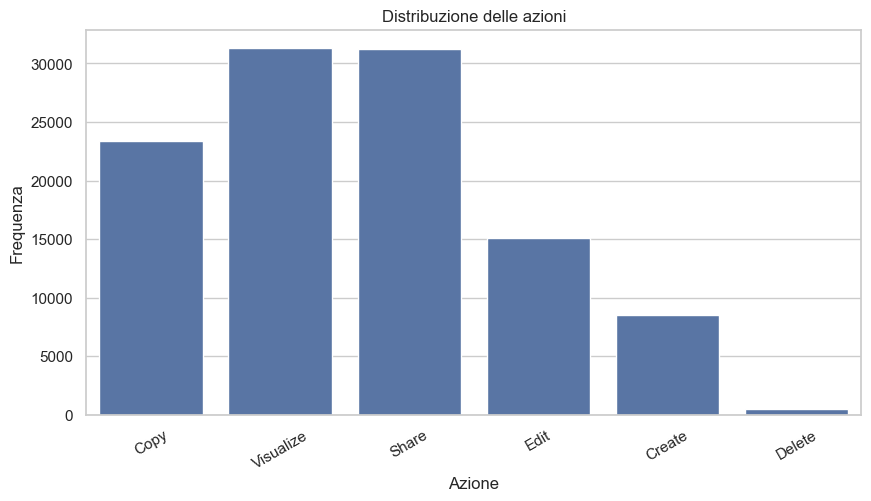

In [162]:
# Mostramos un resumen de cuántas veces realiza cada usuario
# cada tipo de acción.
# Mostriamo un riepilogo di quante volte ogni utente esegue
# ogni tipo di azione.
print("Azioni per utente")
display(activity_df.groupby("user_name")["action_name"].value_counts())

# Gráfico de la distribución global de acciones.
# Grafico della distribuzione globale delle azioni.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_df, x="action_name")
plt.title("Distribuzione delle azioni")
plt.xlabel("Azione")
plt.ylabel("Frequenza")
plt.xticks(rotation=30)
plt.show()

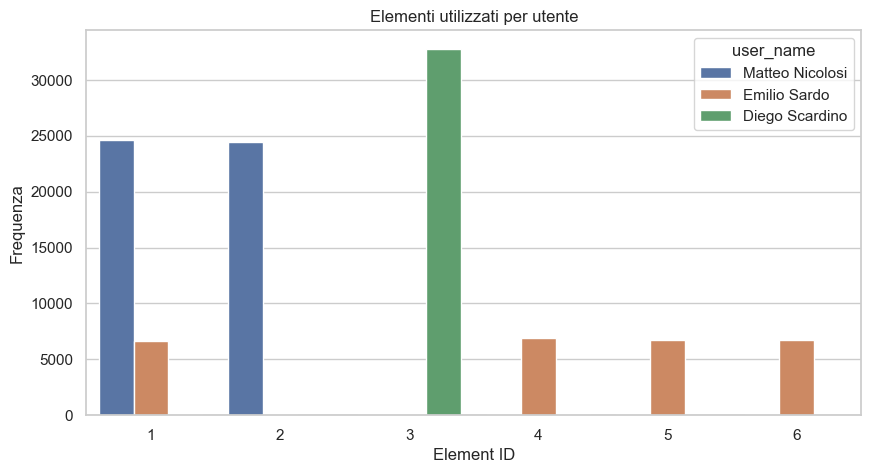

In [163]:
# =========================
# USO DE ELEMENTOS POR USUARIO
# UTILIZZO DEGLI ELEMENTI PER UTENTE
# =========================

# Este gráfico permite ver qué elementos utiliza cada usuario.
# Es útil para observar patrones de acceso y combinaciones habituales.
# Questo grafico permette di vedere quali elementi utilizza ciascun utente.
# È utile per osservare pattern di accesso e combinazioni abituali.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_df, x="element_id", hue="user_name")
plt.title("Elementi utilizzati per utente")
plt.xlabel("Element ID")
plt.ylabel("Frequenza")
plt.show()

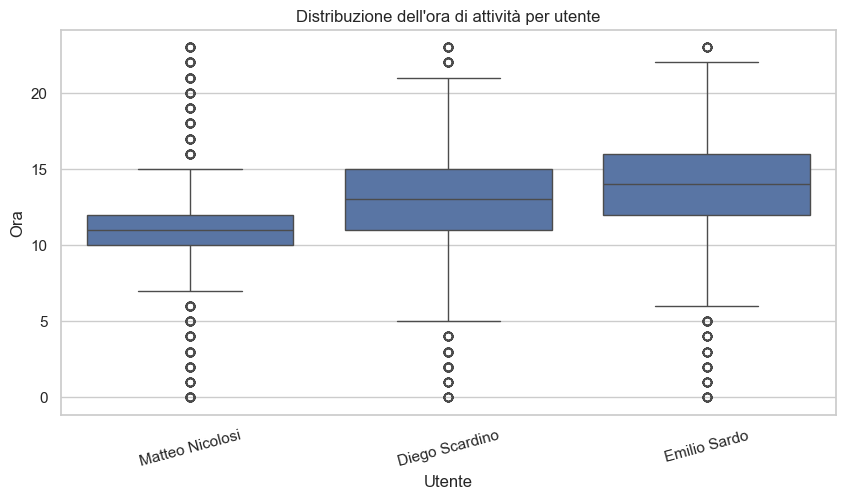

In [164]:
# =========================
# BOXPLOT DE LA HORA DE ACTIVIDAD POR USUARIO
# BOXPLOT DELL'ORA DI ATTIVITÀ PER UTENTE
# =========================

# Este gráfico permite observar la distribución horaria de las actividades
# realizadas por cada usuario.
# Questo grafico permette di osservare la distribuzione oraria delle attività
# svolte da ciascun utente.
plt.figure(figsize=(10, 5))
sns.boxplot(data=activity_df, x="user_name", y="hour")
plt.title("Distribuzione dell'ora di attività per utente")
plt.xlabel("Utente")
plt.ylabel("Ora")
plt.xticks(rotation=15)
plt.show()

# Esta gráfica representa la distribución de la hora de actividad de cada usuario. La línea central dentro de cada caja indica la mediana, 
# mientras que la caja azul recoge el 50% central de las actividades. 
# Los bigotes muestran el rango habitual y los puntos blancos representan valores atípicos. 
# Se observa que cada usuario sigue un patrón horario diferente, aunque también aparecen actividades en horas poco frecuentes, 
# que pueden interpretarse como posibles anomalías

# Questo grafico rappresenta la distribuzione dell’ora di attività di ciascun utente. La linea centrale all’interno di ogni scatola indica la mediana, 
# mentre la scatola blu raccoglie il 50% centrale delle attività.
# I baffi mostrano l’intervallo abituale e i punti bianchi rappresentano valori atipici.
# Si osserva che ogni utente segue un pattern orario differente, anche se compaiono anche attività in orari poco frequenti,
#  che possono essere interpretate come possibili anomalie.

In [165]:
# =========================
# PRUEBA MANUAL DE ANOMALÍAS EN ACTIVITY
# TEST MANUALE DELLE ANOMALIE IN ACTIVITY
# =========================

# Esta celda entrena un modelo de detección de anomalías por usuario
# y permite probar manualmente nuevas actividades.
# Questa cella addestra un modello di rilevamento anomalie per utente
# e permette di testare manualmente nuove attività.

from sklearn.ensemble import IsolationForest

# Variables que usaremos para el modelo.
# Variabili che useremo per il modello.
features_activity = ["element_id", "entity_id", "action_id", "hour", "minute", "day_of_week"]

# Preparamos una copia del dataset de actividad.
# Prepariamo una copia del dataset di attività.
activity_model_df = activity_df.copy()

# Nos aseguramos de que las variables temporales existen.
# Ci assicuriamo che le variabili temporali esistano.
activity_model_df["hour"] = activity_model_df["logged_at"].dt.hour
activity_model_df["minute"] = activity_model_df["logged_at"].dt.minute
activity_model_df["day_of_week"] = activity_model_df["logged_at"].dt.dayofweek

# Entrenamos un modelo por usuario.
# Addestriamo un modello per utente.
activity_user_models = {}

for user_id in sorted(activity_model_df["user_id"].unique()):
    user_data = activity_model_df[activity_model_df["user_id"] == user_id].copy()

    if len(user_data) < 10:
        print(f"Utente {user_id}: dati insufficienti per addestrare il modello.")
        continue

    X_user = pd.get_dummies(
        user_data[features_activity],
        columns=["element_id", "entity_id", "action_id", "day_of_week"],
        dtype=int
    )

    model = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42
    )
    model.fit(X_user)

    activity_user_models[user_id] = {
        "model": model,
        "feature_columns": X_user.columns.tolist()
    }

print("Modelli di Activity addestrati correttamente.")


def predict_activity_anomaly(user_id, element_id, entity_id, action_id, logged_at):
    """
    Prueba manualmente una actividad nueva usando el modelo del usuario.

    Devuelve:
    - prediction: 1 si el caso parece anómalo, 0 si parece normal
    - score: puntuación de rareza

    Testa manualmente una nuova attività usando il modello dell'utente.

    Restituisce:
    - prediction: 1 se il caso sembra anomalo, 0 se sembra normale
    - score: punteggio di rarità
    """
    logged_at = pd.to_datetime(logged_at)

    if user_id not in activity_user_models:
        print(f"Nessun modello disponibile per user_id={user_id}")
        return None, None

    row = pd.DataFrame([{
        "element_id": element_id,
        "entity_id": entity_id,
        "action_id": action_id,
        "hour": logged_at.hour,
        "minute": logged_at.minute,
        "day_of_week": logged_at.dayofweek
    }])

    row_encoded = pd.get_dummies(
        row,
        columns=["element_id", "entity_id", "action_id", "day_of_week"],
        dtype=int
    )

    model_data = activity_user_models[user_id]
    model = model_data["model"]
    feature_columns = model_data["feature_columns"]

    for col in feature_columns:
        if col not in row_encoded.columns:
            row_encoded[col] = 0

    row_encoded = row_encoded[feature_columns]

    raw_prediction = model.predict(row_encoded)[0]   # 1 normal, -1 anomalous
    raw_score = model.decision_function(row_encoded)[0]

    prediction = 1 if raw_prediction == -1 else 0
    score = float(-raw_score)

    print("=== RISULTATO DEL MODELLO ===")
    print("Previsione:", "ANOMALO" if prediction == 1 else "NORMALE")
    print(f"Score di anomalia: {score:.6f}")

    return prediction, score


# Ejemplo de uso:
# Esempio di utilizzo:
predict_activity_anomaly(
    user_id=2,
    element_id=1,
    entity_id=1,
    action_id=1000005,
    logged_at="2026-01-20 13:15:00"
)

Modelli di Activity addestrati correttamente.
=== RISULTATO DEL MODELLO ===
Previsione: ANOMALO
Score di anomalia: 0.041750


(1, 0.041750459992444644)

In [166]:
# =========================
# PREPARACIÓN FINAL DEL DATASET PARA MACHINE LEARNING
# PREPARAZIONE FINALE DEL DATASET PER IL MACHINE LEARNING
# =========================

# En este proyecto no utilizamos rules.py para etiquetar anomalías.
# El objetivo es que el modelo aprenda el comportamiento normal
# de cada usuario directamente a partir de los datos históricos.
#
# In questo progetto non utilizziamo rules.py per etichettare le anomalie.
# L'obiettivo è che il modello impari il comportamento normale
# di ciascun utente direttamente a partire dai dati storici.

# Creamos una copia específica del dataset de actividad para modelado.
# Creiamo una copia specifica del dataset di attività per la modellazione.
activity_ml_df = activity_df.copy()

# Seleccionamos las variables que describen el comportamiento del usuario.
# Selezioniamo le variabili che descrivono il comportamento dell'utente.
features_activity = [
    "user_id",
    "element_id",
    "entity_id",
    "action_id",
    "hour",
    "minute",
    "day_of_week"
]

activity_ml_df = activity_ml_df[features_activity].copy()

# Mostramos una vista previa del dataset final que se utilizará
# para entrenar el modelo de detección de anomalías.
# Mostriamo un'anteprima del dataset finale che verrà utilizzato
# per addestrare il modello di rilevamento anomalie.
display(activity_ml_df.head())

print("Shape del dataset per il machine learning:", activity_ml_df.shape)

,user_id,element_id,entity_id,action_id,hour,minute,day_of_week
0,1,2,1,1000004,11,28,1
1,1,2,1,1000000,9,43,3
2,1,2,1,1000000,10,20,3
3,1,1,1,1000005,12,10,1
4,2,3,1,1000000,15,38,0


Shape del dataset per il machine learning: (110011, 7)


In [167]:
# =========================
# ENTRENAMIENTO DEL MODELO DE ANOMALÍAS POR USUARIO
# ADDESTRAMENTO DEL MODELLO DI ANOMALIE PER UTENTE
# =========================

# Utilizamos IsolationForest porque el objetivo no es clasificar
# con reglas fijas, sino detectar comportamientos poco habituales
# respecto al patrón normal de cada usuario.
# Utilizziamo IsolationForest perché l'obiettivo non è classificare
# con regole fisse, ma rilevare comportamenti poco abituali
# rispetto al pattern normale di ciascun utente.

activity_user_models = {}

for user_id in sorted(activity_ml_df["user_id"].unique()):
    # Filtramos solo las actividades del usuario actual.
    # Filtriamo solo le attività dell'utente corrente.
    user_data = activity_ml_df[activity_ml_df["user_id"] == user_id].copy()

    # Comprobamos que haya suficientes registros para entrenar.
    # Verifichiamo che ci siano abbastanza record per addestrare.
    if len(user_data) < 10:
        print(f"Utente {user_id}: dati insufficienti per addestrare il modello.")
        continue

    # Eliminamos user_id de las variables de entrada porque cada modelo
    # se entrena de forma independiente para un solo usuario.
    # Rimuoviamo user_id dalle variabili di input perché ogni modello
    # viene addestrato in modo indipendente per un solo utente.
    X_user = user_data.drop(columns=["user_id"]).copy()

    # Convertimos las variables categóricas en variables dummy.
    # Convertiamo le variabili categoriche in variabili dummy.
    X_user = pd.get_dummies(
        X_user,
        columns=["element_id", "entity_id", "action_id", "day_of_week"],
        dtype=int
    )

    # Creamos y entrenamos el modelo.
    # Creiamo e addestriamo il modello.
    model = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42
    )
    model.fit(X_user)

    # Guardamos el modelo y las columnas usadas en el entrenamiento.
    # Salviamo il modello e le colonne usate durante l'addestramento.
    activity_user_models[user_id] = {
        "model": model,
        "feature_columns": X_user.columns.tolist()
    }

    print(f"Utente {user_id}: modello addestrato con {len(user_data)} record.")

Utente 1: modello addestrato con 49597 record.
Utente 2: modello addestrato con 33129 record.
Utente 3: modello addestrato con 27285 record.


In [168]:
# =========================
# APLICACIÓN DEL MODELO SOBRE TODO EL DATASET
# APPLICAZIONE DEL MODELLO SU TUTTO IL DATASET
# =========================

# Vamos a aplicar el modelo correspondiente a cada usuario
# sobre todas sus actividades para obtener:
# - una predicción de normalidad/anomalía
# - un score de rareza
#
# Applicheremo il modello corrispondente a ciascun utente
# su tutte le sue attività per ottenere:
# - una previsione di normalità/anomalia
# - uno score di rarità

activity_results_df = activity_df.copy()
activity_results_df["ml_prediction"] = np.nan
activity_results_df["anomaly_score"] = np.nan

for user_id in sorted(activity_results_df["user_id"].unique()):
    if user_id not in activity_user_models:
        print(f"Utente {user_id}: nessun modello disponibile.")
        continue

    user_mask = activity_results_df["user_id"] == user_id
    user_data = activity_results_df.loc[user_mask].copy()

    # Preparamos las mismas variables usadas durante el entrenamiento.
    # Prepariamo le stesse variabili usate durante l'addestramento.
    X_user = user_data[[
        "element_id",
        "entity_id",
        "action_id",
        "hour",
        "minute",
        "day_of_week"
    ]].copy()

    X_user = pd.get_dummies(
        X_user,
        columns=["element_id", "entity_id", "action_id", "day_of_week"],
        dtype=int
    )

    model_data = activity_user_models[user_id]
    model = model_data["model"]
    feature_columns = model_data["feature_columns"]

    # Alineamos las columnas del dataset actual con las columnas
    # exactas usadas en el entrenamiento del modelo.
    # Allineiamo le colonne del dataset attuale con le colonne
    # esatte usate durante l'addestramento del modello.
    for col in feature_columns:
        if col not in X_user.columns:
            X_user[col] = 0

    X_user = X_user[feature_columns]

    # En IsolationForest:
    #  1  = normal
    # -1 = anómalo
    #
    # In IsolationForest:
    #  1  = normale
    # -1 = anomalo
    raw_pred = model.predict(X_user)
    raw_score = model.decision_function(X_user)

    # Convertimos la salida a una codificación más clara:
    # 0 = normal
    # 1 = anómalo
    #
    # Convertiamo l'output in una codifica più chiara:
    # 0 = normale
    # 1 = anomalo
    ml_prediction = np.where(raw_pred == -1, 1, 0)

    # Cuanto más alto sea este valor, más raro parece el caso.
    # Più alto è questo valore, più raro sembra il caso.
    anomaly_score = -raw_score

    activity_results_df.loc[user_mask, "ml_prediction"] = ml_prediction
    activity_results_df.loc[user_mask, "anomaly_score"] = anomaly_score

print("Predizioni generate correttamente.")
display(activity_results_df.head())

Predizioni generate correttamente.


,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,entity_name,hour,minute,day_of_week,date,is_weekday,time_block,ml_prediction,anomaly_score
0,243041,1,2,1,1000004,2026-03-24 11:28:39,Matteo Nicolosi,Copy,Password,11,28,1,2026-03-24,1,morning,0.0,-0.045392
1,243042,1,2,1,1000000,2026-03-12 09:43:11,Matteo Nicolosi,Visualize,Password,9,43,3,2026-03-12,1,morning,0.0,-0.019691
2,243043,1,2,1,1000000,2026-03-12 10:20:46,Matteo Nicolosi,Visualize,Password,10,20,3,2026-03-12,1,morning,0.0,-0.037076
3,243044,1,1,1,1000005,2026-04-07 12:10:38,Matteo Nicolosi,Share,Password,12,10,1,2026-04-07,1,afternoon,0.0,-0.031242
4,243045,2,3,1,1000000,2026-03-09 15:38:28,Diego Scardino,Visualize,Password,15,38,0,2026-03-09,1,afternoon,0.0,-0.034855


Distribuzione delle predizioni per utente


ml_prediction,0.0,1.0
user_name,,
Diego Scardino,31475,1654
Emilio Sardo,25920,1365
Matteo Nicolosi,47117,2480


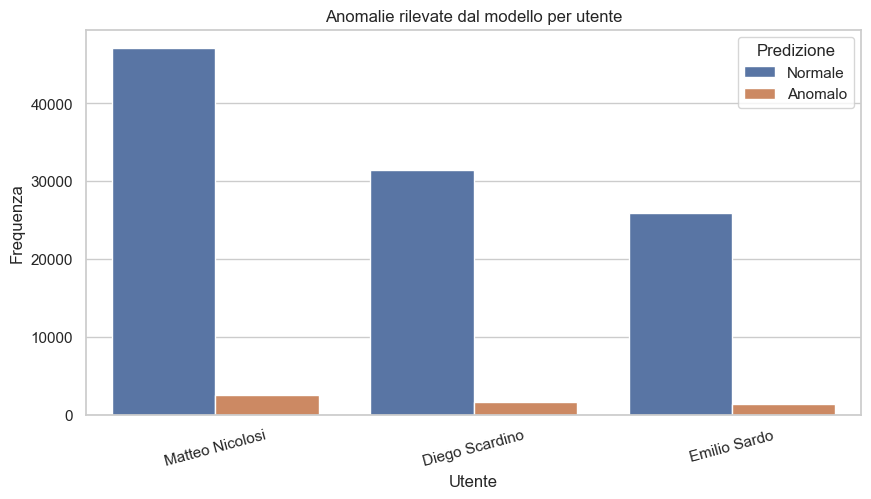

In [169]:
# =========================
# RESUMEN DE ANOMALÍAS DETECTADAS POR USUARIO
# RIEPILOGO DELLE ANOMALIE RILEVATE PER UTENTE
# =========================

# Creamos una columna con el nombre del usuario para que la lectura
# de los resultados sea más clara.
# Creiamo una colonna con il nome dell'utente per rendere più chiara
# la lettura dei risultati.
user_names = {
    1: "Matteo Nicolosi",
    2: "Diego Scardino",
    3: "Emilio Sardo"
}

activity_results_df["user_name"] = activity_results_df["user_id"].map(user_names)

# Mostramos cuántas actividades ha marcado el modelo como normales
# y cuántas como anómalas para cada usuario.
# Mostriamo quante attività il modello ha segnato come normali
# e quante come anomale per ciascun utente.
print("Distribuzione delle predizioni per utente")
display(
    activity_results_df.groupby("user_name")["ml_prediction"].value_counts().unstack(fill_value=0)
)

# Visualización gráfica de las anomalías detectadas por usuario.
# Visualizzazione grafica delle anomalie rilevate per utente.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_results_df, x="user_name", hue="ml_prediction")
plt.title("Anomalie rilevate dal modello per utente")
plt.xlabel("Utente")
plt.ylabel("Frequenza")
plt.xticks(rotation=15)
plt.legend(title="Predizione", labels=["Normale", "Anomalo"])
plt.show()

In [170]:
# =========================
# CASOS ANÓMALOS DETECTADOS POR EL MODELO
# CASI ANOMALI RILEVATI DAL MODELLO
# =========================

# Filtramos únicamente las actividades que el modelo ha marcado como anómalas.
# Filtriamo unicamente le attività che il modello ha contrassegnato come anomale.
activity_anomalies_detected = activity_results_df[activity_results_df["ml_prediction"] == 1].copy()

# Ordenamos los casos por score de anomalía de mayor a menor.
# In questo modo vediamo primero los casos más raros.
# Ordiniamo i casi per score di anomalia dal più alto al più basso.
# In questo modo vediamo prima i casi più rari.
activity_anomalies_detected = activity_anomalies_detected.sort_values(
    by="anomaly_score",
    ascending=False
)

print("Numero totale di anomalie rilevate:", activity_anomalies_detected.shape[0])

# Mostramos los casos más anómalos detectados por el modelo.
# Mostriamo i casi più anomali rilevati dal modello.
display(
    activity_anomalies_detected[
        [
            "activity_log_id",
            "user_id",
            "user_name",
            "element_id",
            "entity_id",
            "action_id",
            "hour",
            "minute",
            "day_of_week",
            "logged_at",
            "anomaly_score"
        ]
    ].head(20)
)

Numero totale di anomalie rilevate: 5499


,activity_log_id,user_id,user_name,element_id,entity_id,action_id,hour,minute,day_of_week,logged_at,anomaly_score
77925,320966,1,Matteo Nicolosi,2,3,1000000,21,8,6,2026-03-15 21:08:42,0.109143
65420,308461,1,Matteo Nicolosi,2,3,1000000,21,32,5,2026-04-04 21:32:36,0.108620
65887,308928,1,Matteo Nicolosi,1,2,1000004,16,59,5,2026-03-14 16:59:50,0.107467
55520,298561,2,Diego Scardino,1,1,1000001,23,59,6,2026-02-22 23:59:54,0.106399
79113,322154,1,Matteo Nicolosi,1,2,1000005,16,4,5,2026-01-03 16:04:14,0.104888
20564,263605,2,Diego Scardino,4,1,1000002,2,59,2,2026-02-11 02:59:38,0.104101
89621,332662,1,Matteo Nicolosi,1,3,1000004,17,44,6,2026-03-29 17:44:54,0.102452
46700,289741,1,Matteo Nicolosi,1,3,1000004,4,52,6,2025-12-21 04:52:03,0.101276
10016,253057,1,Matteo Nicolosi,2,2,1000000,18,3,5,2026-01-24 18:03:23,0.098556
33534,276575,1,Matteo Nicolosi,2,3,1000005,23,32,1,2026-01-20 23:32:38,0.096768


In [ ]:
# =========================
# PRUEBA MANUAL DE UNA NUEVA ACTIVIDAD
# TEST MANUALE DI UNA NUOVA ATTIVITÀ
# =========================

def predict_new_activity(user_id, element_id, entity_id, action_id, logged_at):
    """
    Prueba manualmente una nueva actividad con el modelo del usuario.

    Devuelve:
    - prediction: 0 si parece normal, 1 si parece anómala
    - anomaly_score: cuanto mayor sea, más raro parece el caso

    Testa manualmente una nuova attività con il modello dell'utente.

    Restituisce:
    - prediction: 0 se sembra normale, 1 se sembra anomala
    - anomaly_score: più è alto, più raro sembra il caso
    """
    logged_at = pd.to_datetime(logged_at)

    if user_id not in activity_user_models:
        print(f"Nessun modello disponibile per user_id={user_id}")
        return None, None

    # Construimos la fila con la misma estructura lógica usada en el entrenamiento.
    # Costruiamo la riga con la stessa struttura logica usata durante l'addestramento.
    row = pd.DataFrame([{
        "element_id": element_id,
        "entity_id": entity_id,
        "action_id": action_id,
        "hour": logged_at.hour,
        "minute": logged_at.minute,
        "day_of_week": logged_at.dayofweek
    }])

    # Aplicamos el mismo proceso de codificación.
    # Applichiamo lo stesso processo di codifica.
    row_encoded = pd.get_dummies(
        row,
        columns=["element_id", "entity_id", "action_id", "day_of_week"],
        dtype=int
    )

    model_data = activity_user_models[user_id]
    model = model_data["model"]
    feature_columns = model_data["feature_columns"]

    # Alineamos las columnas con las del entrenamiento.
    # Allineiamo le colonne con quelle del training.
    for col in feature_columns:
        if col not in row_encoded.columns:
            row_encoded[col] = 0

    row_encoded = row_encoded[feature_columns]

    raw_pred = model.predict(row_encoded)[0]
    raw_score = model.decision_function(row_encoded)[0]

    prediction = 1 if raw_pred == -1 else 0
    anomaly_score = float(-raw_score)

    print("=== RISULTATO DEL MODELLO ===")
    print("Previsione:", "ANOMALO" if prediction == 1 else "NORMALE")
    print(f"Score di anomalia: {anomaly_score:.6f}")

    return prediction, anomaly_score


# Ejemplo de uso:
# Esempio di utilizzo:
predict_new_activity(
    user_id=2,
    element_id=1,
    entity_id=1,
    action_id=1000005,
    logged_at="2026-01-20 13:15:00"
)

=== RISULTATO DEL MODELLO ===
Previsione: ANOMALO
Score di anomalia: 0.041750


(1, 0.041750459992444644)

In [172]:
activity_results_df["ml_prediction"].value_counts()

ml_prediction
0.0    104512
1.0      5499
Name: count, dtype: int64

In [173]:
activity_results_df["anomaly_score"].describe()

count    110011.000000
mean         -0.025007
std           0.016620
min          -0.059844
25%          -0.035963
50%          -0.026642
75%          -0.016861
max           0.109143
Name: anomaly_score, dtype: float64

In [174]:
predict_new_activity(
    user_id=1,
    element_id=1,
    entity_id=1,
    action_id=1000000,
    logged_at="2026-04-16 10:30:00"
)

=== RISULTATO DEL MODELLO ===
Previsione: NORMALE
Score di anomalia: -0.043211


(0, -0.04321060681469141)

In [175]:
predict_new_activity(
    user_id=1,
    element_id=5,
    entity_id=3,
    action_id=1000003,
    logged_at="2026-04-16 02:15:00"
)

=== RISULTATO DEL MODELLO ===
Previsione: ANOMALO
Score di anomalia: 0.138528


(1, 0.1385275429342031)

In [176]:
predict_new_activity(
    user_id=2,
    element_id=1,
    entity_id=1,
    action_id=1000005,
    logged_at="2026-04-16 16:20:00"
)

=== RISULTATO DEL MODELLO ===
Previsione: ANOMALO
Score di anomalia: 0.053745


(1, 0.05374476765526637)

In [177]:
predict_new_activity(
    user_id=1,
    element_id=1,
    entity_id=1,
    action_id=1000000,
    logged_at='2026-04-14 11:00:30'
)

=== RISULTATO DEL MODELLO ===
Previsione: NORMALE
Score di anomalia: -0.006019


(0, -0.006018932819992551)

# CONCLUSIONES FINALES

A lo largo de este proyecto se han cargado, analizado y preparado dos fuentes principales de datos, **Login Log** y **Activity Log**, con el objetivo de construir una primera **PoC de detección de anomalías** en el comportamiento de los usuarios dentro del sistema. Para ello, se han transformado las variables temporales más relevantes, generando información útil como la **hora**, el **minuto**, el **día de la semana** y la **duración de la sesión**, lo que ha permitido enriquecer el análisis y preparar correctamente los datos para el modelado.

Uno de los aspectos más importantes del proyecto ha sido la construcción de un flujo de trabajo coherente entre la **base de datos PostgreSQL**, la **generación sintética de datos**, el **notebook de análisis** y el **modelo final de machine learning**. Esto ha permitido trabajar siempre sobre la misma estructura de datos y mantener consistencia entre la fase exploratoria, la fase de entrenamiento y la posterior integración en la aplicación.

A nivel funcional, se ha definido para cada usuario un patrón de comportamiento esperado en términos de **franja horaria habitual**, **elementos utilizados**, **entidades accesibles** y **acciones realizadas**. Sin embargo, estas reglas no se han utilizado para etiquetar automáticamente las anomalías del modelo final, sino como referencia para construir un dataset sintético coherente con el dominio del problema. De este modo, el sistema no depende de una clasificación manual fija, sino que aprende directamente a partir de los datos generados.

Además, se ha desarrollado un proceso de **generación sintética de datos** para poblar la base de datos con registros realistas de `login_log` y `activity_log`, ajustando progresivamente la proporción de comportamientos normales y anómalos. Este proceso ha requerido varias iteraciones, ya que en un primer momento la distribución de anomalías no resultaba suficientemente realista. Tras revisar los patrones definidos para cada usuario y refinar la lógica de generación, se ha conseguido una base de datos más coherente, adecuada para entrenar y validar una primera aproximación de detección de anomalías.

Sobre esta base, el enfoque final de machine learning se ha orientado a un modelo de **detección de anomalías no supervisada**, en lugar de un clasificador tradicional entrenado con etiquetas manuales. En concreto, se ha utilizado **IsolationForest**, entrenando **un modelo independiente por usuario**, con el objetivo de que cada modelo aprenda el comportamiento normal asociado a ese usuario y detecte desviaciones respecto a dicho patrón. Este enfoque resulta especialmente adecuado para el problema, ya que una misma acción puede ser completamente normal para un usuario y anómala para otro.

A diferencia de un sistema basado en reglas fijas, el modelo desarrollado no decide si una actividad es anómala porque incumpla explícitamente una condición predefinida, sino porque se aleja del comportamiento habitual aprendido a partir de los datos. Por ejemplo, el modelo puede considerar anómala una actividad realizada en una hora poco frecuente, sobre un elemento poco habitual o mediante una combinación de acción y entidad distinta de la observada normalmente para ese usuario. De este modo, el sistema se orienta realmente al **aprendizaje del comportamiento** y no solo a la reproducción de reglas conocidas.

Durante las pruebas realizadas, el sistema ha mostrado un comportamiento coherente, identificando como normales los casos alineados con el patrón habitual y detectando como anómalos aquellos que presentan combinaciones extrañas o poco frecuentes. Además, el uso de un **score de anomalía** ha permitido no solo clasificar los casos en normales o anómalos, sino también ordenar las actividades según su grado de rareza, lo que puede resultar especialmente útil en un futuro entorno de revisión o auditoría.

En conjunto, puede concluirse que esta PoC cumple adecuadamente su objetivo principal: demostrar que es posible construir un sistema capaz de **aprender el comportamiento normal de cada usuario** y detectar automáticamente desviaciones relevantes sin depender de una etiqueta manual generada por reglas. El enfoque desarrollado resulta apropiado para una primera fase del proyecto, al combinar **datos sintéticos coherentes**, **análisis exploratorio**, **detección de anomalías por usuario** e **integración con la base de datos y la aplicación**.

Como líneas de mejora futura, sería recomendable **ampliar el número de usuarios y casuísticas reales**, incorporar **secuencias completas de comportamiento** como `login -> actividad -> logout`, introducir **features agregadas por usuario y por día**, utilizar **datos reales validados por negocio** y evolucionar hacia un **sistema en tiempo real** capaz de bloquear, alertar o escalar automáticamente las acciones más sospechosas. Todo ello permitiría mejorar progresivamente la precisión, la capacidad de detección y la utilidad operativa del sistema en un entorno real.

---

# CONCLUSIONI FINALI

Nel corso di questo progetto sono state caricate, analizzate e preparate due principali fonti di dati, **Login Log** e **Activity Log**, con l’obiettivo di costruire una prima **PoC per il rilevamento delle anomalie** nel comportamento degli utenti all’interno del sistema. A tal fine, sono state trasformate le variabili temporali più rilevanti, generando informazioni utili come **ora**, **minuto**, **giorno della settimana** e **durata della sessione**, così da arricchire l’analisi e preparare correttamente i dati per il modellamento.

Uno degli aspetti più importanti del progetto è stato la costruzione di un flusso di lavoro coerente tra il **database PostgreSQL**, la **generazione sintetica dei dati**, il **notebook di analisi** e il **modello finale di machine learning**. Questo ha permesso di lavorare sempre sulla stessa struttura dati e di mantenere coerenza tra la fase esplorativa, la fase di addestramento e la successiva integrazione nell’applicazione.

Dal punto di vista funzionale, per ciascun utente è stato definito un pattern di comportamento atteso in termini di **fascia oraria abituale**, **elementi utilizzati**, **entità accessibili** e **azioni eseguite**. Tuttavia, queste regole non sono state utilizzate per etichettare automaticamente le anomalie del modello finale, bensì come riferimento per costruire un dataset sintetico coerente con il dominio del problema. In questo modo, il sistema non dipende da una classificazione manuale fissa, ma apprende direttamente dai dati generati.

Inoltre, è stato sviluppato un processo di **generazione sintetica dei dati** per popolare il database con record realistici di `login_log` e `activity_log`, regolando progressivamente la proporzione tra comportamenti normali e anomali. Questo processo ha richiesto varie iterazioni, poiché inizialmente la distribuzione delle anomalie non risultava sufficientemente realistica. Dopo aver rivisto i pattern definiti per ciascun utente e perfezionato la logica di generazione, si è ottenuta una base dati più coerente, adeguata per addestrare e validare una prima soluzione di rilevamento delle anomalie.

Su questa base, l’approccio finale di machine learning è stato orientato verso un modello di **rilevamento delle anomalie non supervisionato**, invece che verso un classificatore tradizionale addestrato con etichette manuali. In particolare, è stato utilizzato **IsolationForest**, addestrando **un modello indipendente per ciascun utente**, con l’obiettivo che ogni modello impari il comportamento normale associato a quell’utente e rilevi le deviazioni rispetto a tale pattern. Questo approccio risulta particolarmente adatto al problema, poiché una stessa azione può essere completamente normale per un utente e anomala per un altro.

A differenza di un sistema basato su regole fisse, il modello sviluppato non decide se un’attività è anomala perché viola esplicitamente una condizione predefinita, ma perché si discosta dal comportamento abituale appreso dai dati. Per esempio, il modello può considerare anomala un’attività eseguita in un orario poco frequente, su un elemento poco abituale o tramite una combinazione di azione ed entità diversa da quella normalmente osservata per quell’utente. In questo modo, il sistema è realmente orientato all’**apprendimento del comportamento** e non soltanto alla riproduzione di regole già note.

Durante le prove effettuate, il sistema ha mostrato un comportamento coerente, identificando come normali i casi allineati al pattern abituale e rilevando come anomali quelli che presentano combinazioni strane o poco frequenti. Inoltre, l’uso di un **anomaly score** ha permesso non solo di classificare i casi in normali o anomali, ma anche di ordinare le attività in base al loro grado di rarità, aspetto particolarmente utile in un futuro contesto di revisione o audit.

Nel complesso, si può concludere che questa PoC raggiunge adeguatamente il suo obiettivo principale: dimostrare che è possibile costruire un sistema capace di **apprendere il comportamento normale di ciascun utente** e rilevare automaticamente deviazioni rilevanti senza dipendere da un’etichetta manuale generata da regole. L’approccio sviluppato risulta appropriato per una prima fase del progetto, in quanto combina **dati sintetici coerenti**, **analisi esplorativa**, **rilevamento delle anomalie per utente** e **integrazione con il database e con l’applicazione**.

Come possibili sviluppi futuri, sarebbe consigliabile **ampliare il numero di utenti e di casistiche reali**, includere **sequenze complete di comportamento** come `login -> attività -> logout`, introdurre **feature aggregate per utente e per giorno**, utilizzare **dati reali validati dal business** ed evolvere verso un **sistema in tempo reale** capace di bloccare, segnalare o sottoporre automaticamente a revisione le azioni più sospette. Tutto ciò permetterebbe di migliorare progressivamente la precisione, la capacità di rilevamento e l’utilità operativa del sistema in un contesto reale.

En este proyecto, el machine learning se usa para complementar las reglas, no para sustituirlas.

Las reglas detectan anomalías obvias porque están definidas previamente.
El machine learning sirve para aprender patrones de comportamiento y detectar casos raros que no están escritos explícitamente en una regla.